In [112]:
# # Test Case
# # df1
# # 2014-10-01 08:00:00
# # windspeed:
# ws = 1.75
# # temperature: (period of day)
# t_max = 31.25
# t_min = 21.68

# #solar radiation
# Srad = 81.28

# # elevation above sea level, m  (austin, change later)
# z=149.0472

# #relative humidity 
# RH_min = 48.37
# RH_max = 95.1

# #Number of days in the year
# J=273

# #Coordination
# coor1 = (-98.6105, 30.3989)# (lon, lat)


In [2]:
import datetime
from datetime import date
from datetime import datetime
import math as m
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline




In [3]:
# Read datasets and set the index to be the date
df1 = pd.read_csv('../datasets/TX-Data/met_station/met_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('../datasets/TX-Data/met_station/met_2.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('../datasets/TX-Data/met_station/met_3.dat', sep=",", parse_dates=["Date"], index_col="Date")
df4 = pd.read_csv('../datasets/TX-Data/met_station/met_4.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('../datasets/TX-Data/met_station/met_5.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('../datasets/TX-Data/met_station/met_6.dat', sep=",", parse_dates=["Date"], index_col="Date")

In [4]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [5]:
remove_spaces(df1)

In [6]:
# import our timeframe
time2 =df1.index.to_list()
result=[]
for i in time2:
    i=i.date()
    result.append(i)
    
# function to find unique days
def unique(list1):
    x = np.array(list1)
    uni =np.unique(x)
    return uni
t=list(unique(result))



In [7]:
#prepare paremeters in required form
import datetime
def find_configue(time):
    time=str(time)

    # number of day in a year
    datem = datetime.datetime.strptime(time,"%Y-%m-%d")
    d1=date(datem.year,datem.month,datem.day)
    d0 = date(datem.year,1,1)
    delta = d1 - d0
    J=delta.days
    D = df1.loc[time]

    #temperature
    Tair=D.iloc[:,1]
    temperature=[]
    for i in range(len(D)):
        temperature.append(Tair[i])
    t_max = None
    for num in temperature:
        if (t_max is None or num > t_max):
            t_max = num

    t_min =None
    for t in temperature:
        if(t_min is None or t < t_min):
            t_min = t


    #RH
    RH = D.iloc[:,2]
    relative_humidity=[]
    for i in range(len(D)):
        relative_humidity.append(RH[i])
    RH_max = None
    for num in relative_humidity:
        if (RH_max is None or num > RH_max):
            RH_max = num

    RH_min =None
    for t in relative_humidity:
        if(RH_min is None or t < RH_min):
            RH_min = t


    #Srad
    Srad = D.iloc[:,5]


    #ws
    ws = D.iloc[:,3]

    #Coordination
    coor1 = (-98.6105, 30.3989)# (lon, lat)

    # elevation above sea level, m  (austin, change later)
    z=149.0472
    return J, t_max, t_min, RH_max, RH_min, Srad, ws, z, coor1

In [8]:
def Find_ET0(ws,t_max,t_min,Srad,z,RH_min,RH_max,J,coor1):
    J, t_max, t_min, RH_max, RH_min, Srad, ws, z, coor1=find_configue(time)
    t_mean = (t_max+t_min)*(1/2)
    u_0 = ws
    u_2 = u_0 * 4.87/(np.log(67.8 * u_0 - 5.42))
    delta = 4098 * (0.6108*m.exp(17.27*t_mean/(t_mean+237.3)))*(1/(t_mean+237.2))**2
    P = 101.3*(((293-0.0065*z)/293)**5.26)
    p_constant = 0.000665*P
    DT = delta/(delta + p_constant*(1+0.34*u_2))
    PT = p_constant/(delta + p_constant*(1+0.34*u_2))
    TT = (900/(t_mean+273))*u_2
    eT_max= 0.6108*m.exp(17.27*t_max/(t_max+237.3))
    eT_min= 0.6108*m.exp(17.27*t_min/(t_min+237.3))
    es = (eT_max+eT_min)/2
    ea = ((eT_min)*(RH_max/100)+(eT_max)*(RH_min/100))/2
    dr = 1+0.033*m.cos(2*m.pi/365*J)
    Sd = 0.409*m.sin(2*m.pi/365*J-1.39)
    Longitude= coor1[1]
    Ws = np.arccos(-1*m.tan(Sd)*m.tan(Longitude))
    Ra = 24*60/m.pi*0.082*dr*((Ws*m.sin(Longitude)*m.sin(Sd))+(m.cos(Longitude)*m.cos(Sd)*m.sin(Ws)))
    Rso = (0.75 + 0.00002*z)*Ra
    a = 0.23 # albedo or canopy reflection coefficient
    Rns = (1-a)*Srad
    Rnl= 4.903 *(10**(-9))*(((t_max+273.14)**4+(t_min+273.16)**4)/2)*(0.34-0.14*(ea)**(1/2))*(1.35*Srad/Rso-0.35)
    #Rn= Rns -Rnl
    Rn= Rnl -Rns
    Rng = Rn *0.408
    ETrad = DT*Rng
    ETwind = PT * TT *(es-ea)
    ET0=ETrad+ETwind
    return ET0



In [9]:
time2 =df1.index.to_list()
result=[]
for i in time2:
    i=i.date()
    result.append(i)
    
# function to find unique days
def unique(list1):
    x = np.array(list1)
    uni =np.unique(x)
    return uni
t=list(unique(result))

ET0_list=[]
for i in t:
    time = str(i)
    J, t_max, t_min, RH_max, RH_min, Srad, ws, z, coor1=find_configue(time)
    ET0=Find_ET0(ws,t_max,t_min,Srad,z,RH_min,RH_max,J,coor1)
    ET0_list.append(ET0)
df=pd.concat(ET0_list[0:len(ET0_list)-1])
df.columns =['ET0']
df


Date
2014-10-01 00:00:00    0.772937
2014-10-01 01:00:00    0.850264
2014-10-01 02:00:00    1.263452
2014-10-01 03:00:00    1.332716
2014-10-01 04:00:00    0.958963
                         ...   
2021-08-31 19:00:00    0.783887
2021-08-31 20:00:00    0.374133
2021-08-31 21:00:00    0.274842
2021-08-31 22:00:00    1.082060
2021-08-31 23:00:00    1.330537
Length: 60648, dtype: float64

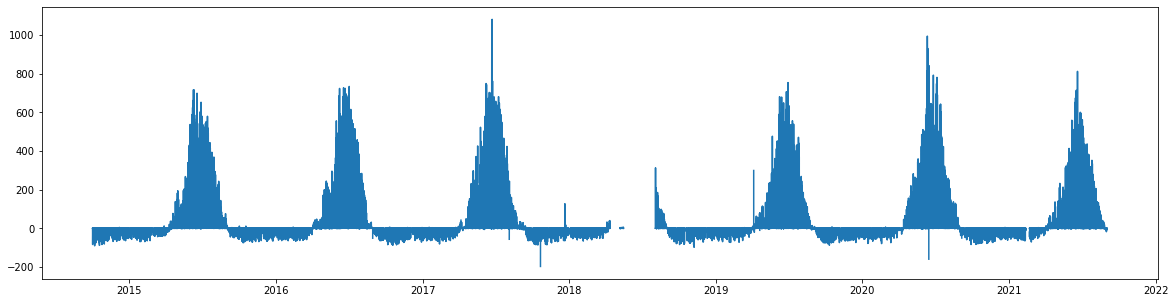

In [10]:
plt.figure(figsize=(20,5))
plt.plot(df.index, df)

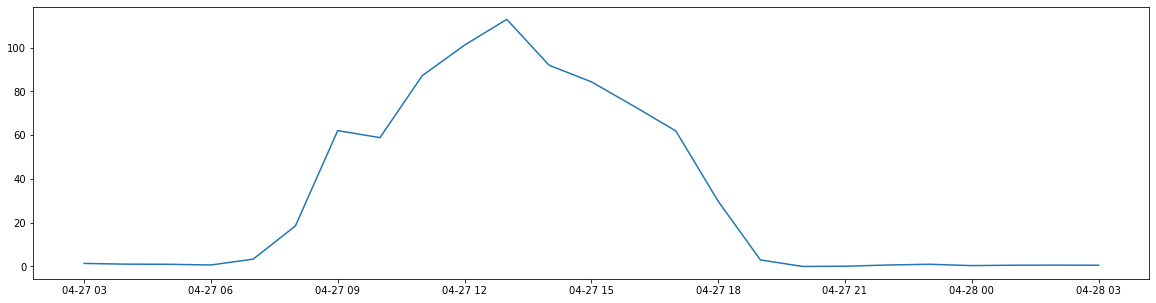

In [11]:
plt.figure(figsize=(20,5))
plt.plot(df[4995:5020].index, df[4995:5020])


##### Steps

In [12]:
# https://edis.ifas.ufl.edu/pdf/AE/AE45900.pdf

In [13]:
#Step1
t_mean = (t_max+t_min)*(1/2)

In [14]:
#Step2 (W m^-2)
Srad = Srad

In [15]:
#Step3 Wind Speed (m/s-1)
u_0 = ws
u_2 = u_0 * 4.87/(np.log(67.8 * u_0 - 5.42))

In [16]:
#Step4 slope of saturation
delta = 4098 * (0.6108*m.exp(17.27*t_mean/(t_mean+237.3)))*(1/(t_mean+237.2))**2

In [17]:
#Step5 Atomspheric Pressure (kpa)
P= 101.3*(((293-0.0065*z)/293)**5.26)

In [18]:
#Step6 Psychrometric constant (kPa C^-1)
p_constant = 0.000665*P

In [19]:
#Step7 Delta Term
DT = delta/(delta + p_constant*(1+0.34*u_2))

In [20]:
#Step8 Psi Term
PT = p_constant/(delta + p_constant*(1+0.34*u_2))

In [21]:
#Step9 Temperature Term 
TT = (900/(t_mean+273))*u_2

In [22]:
#Step10 mean saturation vapor pressure (es) derieved from air tempuature (kPa)
eT_max= 0.6108*m.exp(17.27*t_max/(t_max+237.3))
eT_min= 0.6108*m.exp(17.27*t_min/(t_min+237.3))
# es mean (kpa)
es = (eT_max+eT_min)/2

In [23]:
#Step11 Actual vapor pressure(ea) derieved from relative humidty (absence of huminity data)
ea = ((eT_min)*(RH_max/100)+(eT_max)*(RH_min/100))/2

In [24]:
print(ea,es)

2.546419960378248 3.4033947612646993


In [25]:
#Step12 The inverse relative distance Earth-Sun(dr)
# Solar declination(Sd)
dr = 1+0.033*m.cos(2*m.pi/365*J)
Sd = 0.409*m.sin(2*m.pi/365*J-1.39)


In [26]:
#Step13 Conversion of Latitude in degree to radians(pass)
Longitude= coor1[1]

#Step14 Sunset hour angel 
Ws = np.arccos(-1*m.tan(Sd)*m.tan(Longitude))

In [27]:
# Step15 Ectraterrestrial radiation
Ra = 24*60/m.pi*0.082*dr*((Ws*m.sin(Longitude)*m.sin(Sd))+(m.cos(Longitude)*m.cos(Sd)*m.sin(Ws)))


In [28]:
#Step16 Clear sky solar radiation(Rso)
Rso = (0.75 + 0.00002*z)*Ra
print(Rso)

9.692650669180967


In [29]:
# Step17 Net solar or net shortwave radiation(Rns)
a = 0.23 # albedo or canopy reflection coefficient
Rns = (1-a)*Srad

In [30]:
print(Rns)

Date
2021-09-01    0.0
Name: Srad, dtype: float64


In [31]:
# Step18 Net outcoming long wave solar radiation(Rnl)
Rnl= 4.903 *(10**(-9))*(((t_max+273.14)**4+(t_min+273.16)**4)/2)*(0.34-0.14*(ea)**(1/2))*(1.35*Srad/Rso-0.35)
print(Rnl)

Date
2021-09-01   -1.606884
Name: Srad, dtype: float64


In [32]:
#Step19 Net radiation(Rng) (mm)
#Rn= Rns -Rnl
Rn=Rnl-Rns
Rng = Rn *0.408


In [33]:
# Final Step
# Radiation Term(ETrad) (mm*d^-1)
ETrad = DT*Rng

#Wind Term(ETwind)((mm*d^-1))
ETwind = PT * TT *(es-ea)

In [34]:
ET0=ETrad+ETwind
print(ET0)

Date
2021-09-01    0.515554
dtype: float64
